In [232]:
from google.colab import drive
drive.mount('/content.drive/')

Drive already mounted at /content.drive/; to attempt to forcibly remount, call drive.mount("/content.drive/", force_remount=True).


In [233]:
fielpath = "/content.drive/MyDrive/ML/Loan prediction.csv"

In [234]:
import pandas as pd

In [235]:
data = pd.read_csv(fielpath)

In [236]:
df = pd.DataFrame(data)

#EDA

In [237]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [238]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [239]:
data.shape

(614, 13)

In [240]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [241]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [242]:
data.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


#Values Count Check

In [243]:
data["Gender"].value_counts()

,count
Gender,
Male,489
Female,112


In [244]:
data["Married"].value_counts()

,count
Married,
Yes,398
No,213


In [245]:
data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [246]:
data["Education"].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [247]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [248]:
data["Property_Area"].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


In [249]:
data["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [250]:
data['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [251]:
data['Credit_History'].value_counts()

,count
Credit_History,
1.0,475
0.0,89


#Unique Values Check

In [252]:
data['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [253]:
data['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [254]:
data['Education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [255]:
data['Self_Employed'].unique()

array(['No', 'Yes', nan], dtype=object)

In [256]:
data['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [257]:
data['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [258]:
data['Credit_History'].unique()

array([ 1.,  0., nan])

In [259]:
data['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [260]:
data['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

#Replacing Categorial column with Mode

In [261]:
cat_cols = ['Gender','Married','Dependents',
            'Self_Employed','Credit_History']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [262]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [263]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [264]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [265]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


#Univariate Data Analysis

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt

#Histogram For Numerical Values

#Visualization of Numerical Columns

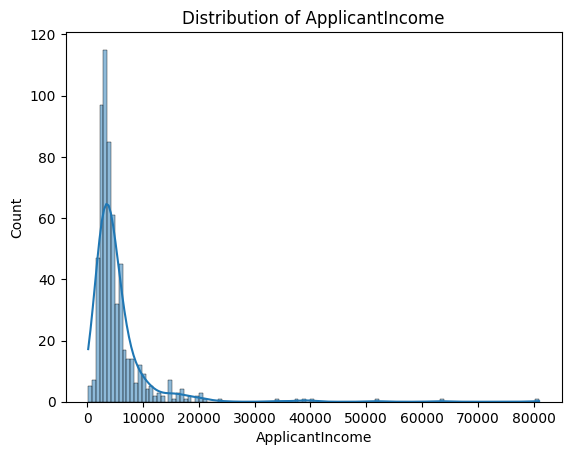

<Figure size 400x400 with 0 Axes>

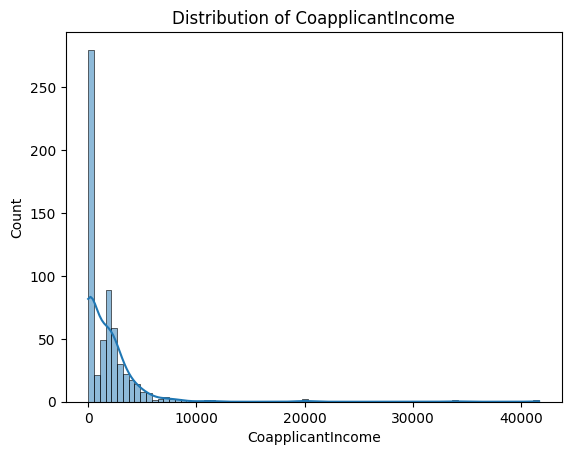

<Figure size 400x400 with 0 Axes>

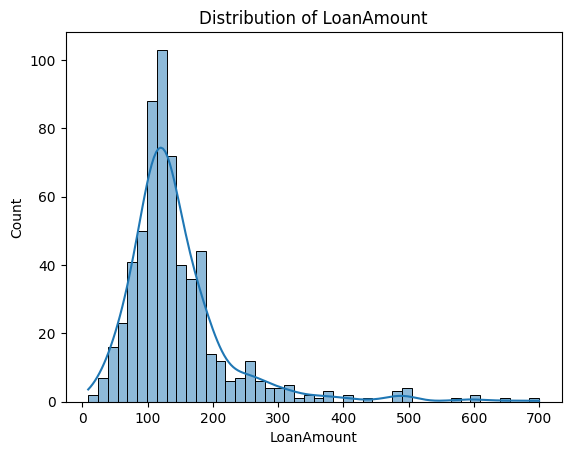

<Figure size 400x400 with 0 Axes>

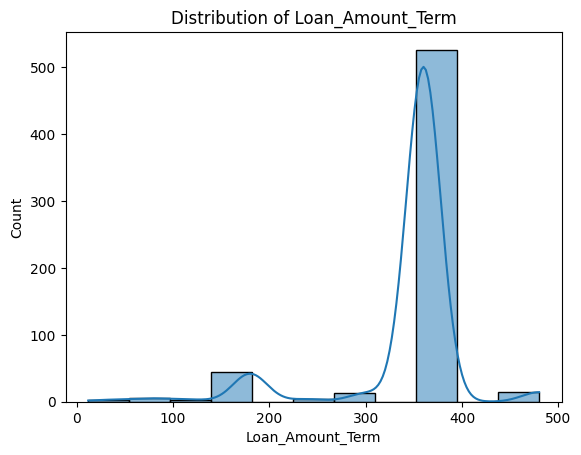

<Figure size 400x400 with 0 Axes>

In [267]:
numerical_cols = ['ApplicantIncome',
            'CoapplicantIncome',
            'LoanAmount',
            'Loan_Amount_Term']

for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.figure(figsize=(4,4))
    plt.show()
    print("\n\n")

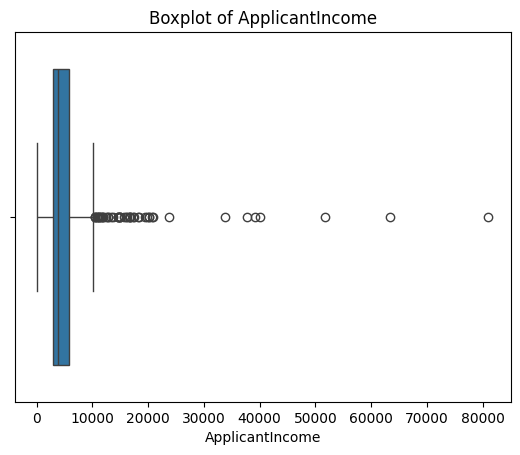

<Figure size 400x400 with 0 Axes>

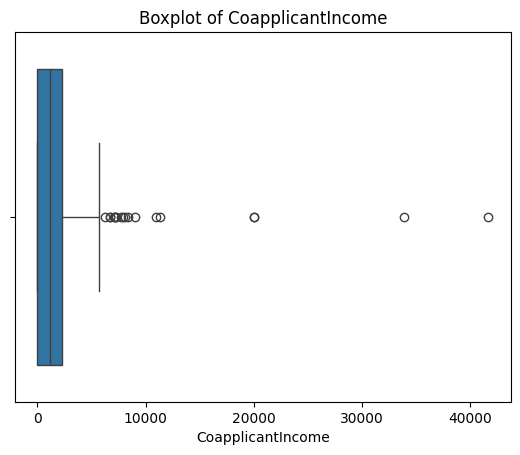

<Figure size 400x400 with 0 Axes>

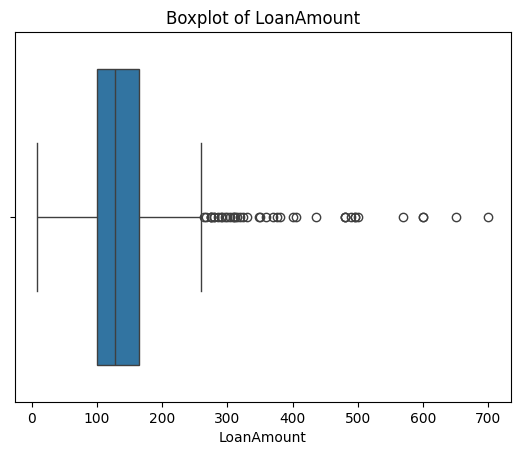

<Figure size 400x400 with 0 Axes>

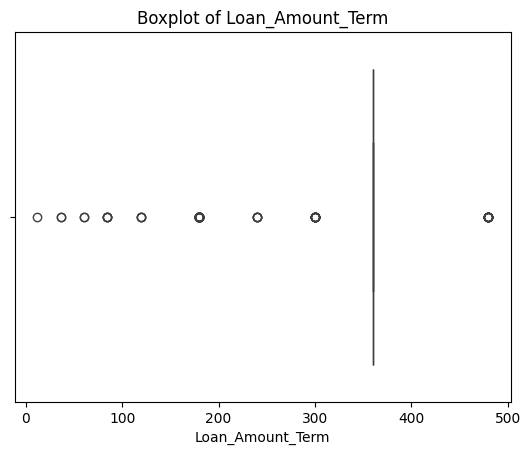

<Figure size 400x400 with 0 Axes>

In [268]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.figure(figsize=(4,4))
    plt.show()

#Visualization on Categorical columns

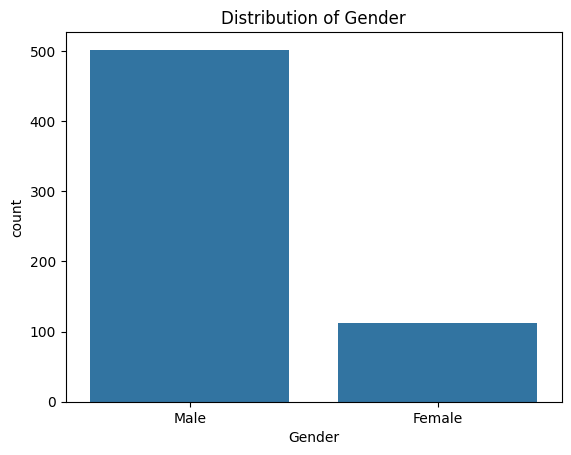

<Figure size 600x400 with 0 Axes>

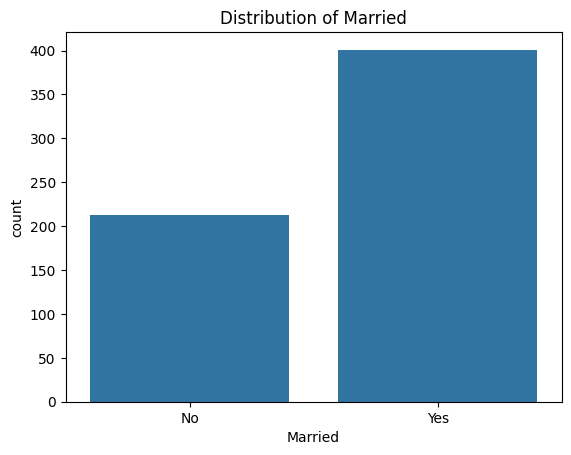

<Figure size 600x400 with 0 Axes>

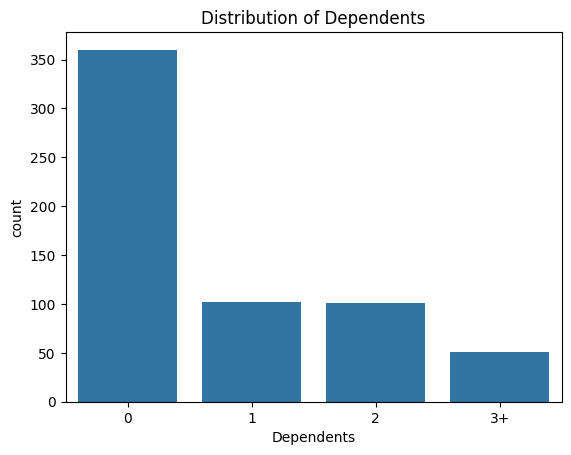

<Figure size 600x400 with 0 Axes>

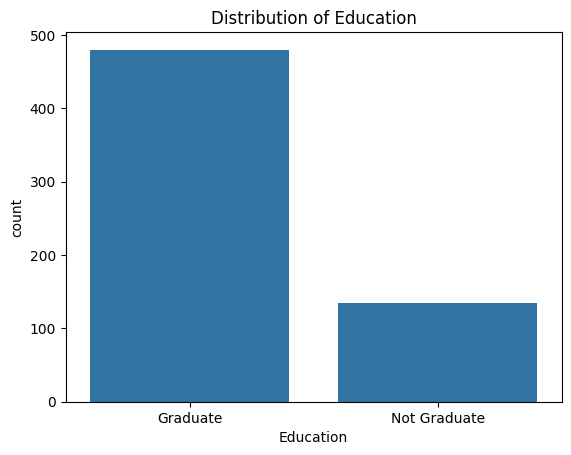

<Figure size 600x400 with 0 Axes>

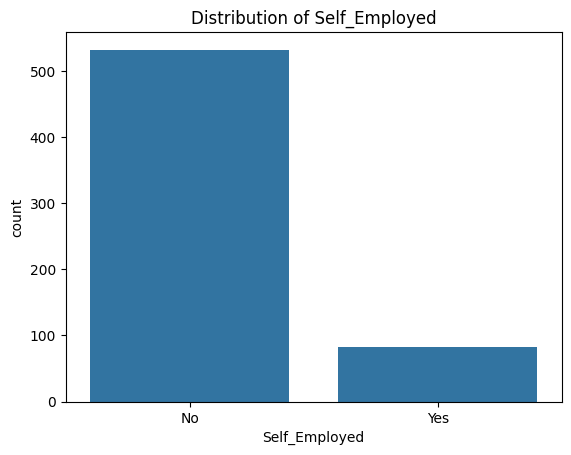

<Figure size 600x400 with 0 Axes>

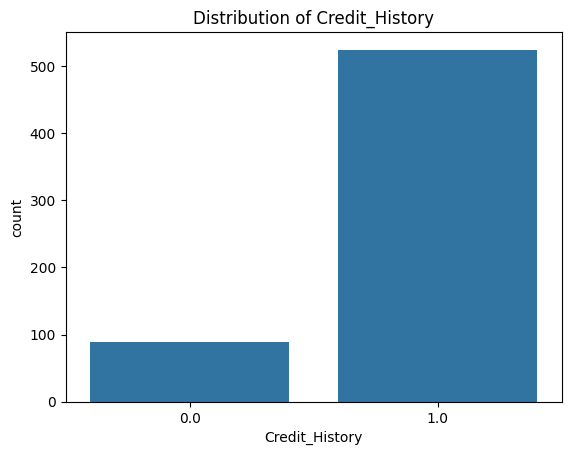

<Figure size 600x400 with 0 Axes>

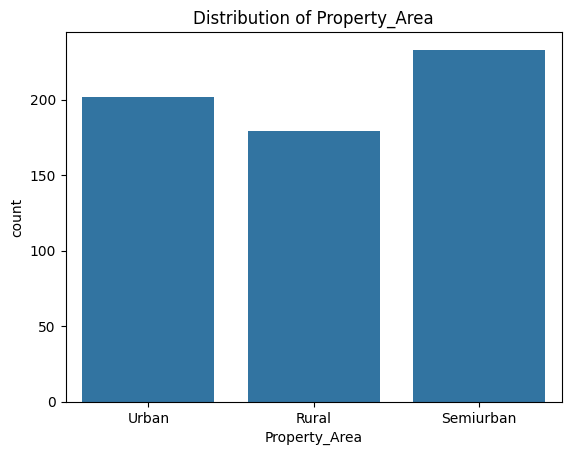

<Figure size 600x400 with 0 Axes>

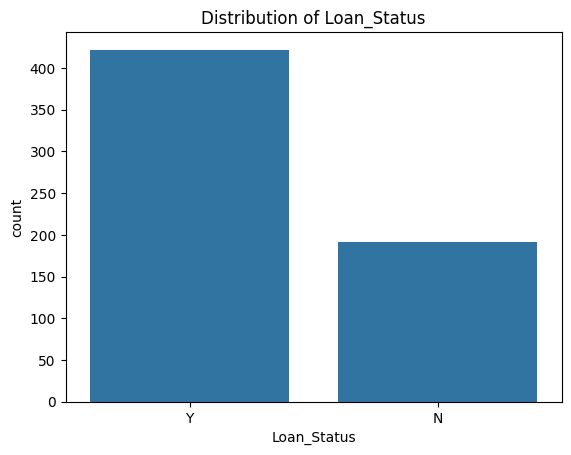

<Figure size 600x400 with 0 Axes>

In [269]:
categorial_cols = ['Gender','Married','Dependents',
            'Education','Self_Employed',
            'Credit_History',
            'Property_Area','Loan_Status']

for col in categorial_cols:
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.figure(figsize=(6,4))
    plt.show()

#Bivariate Analysis

In [270]:
df.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000


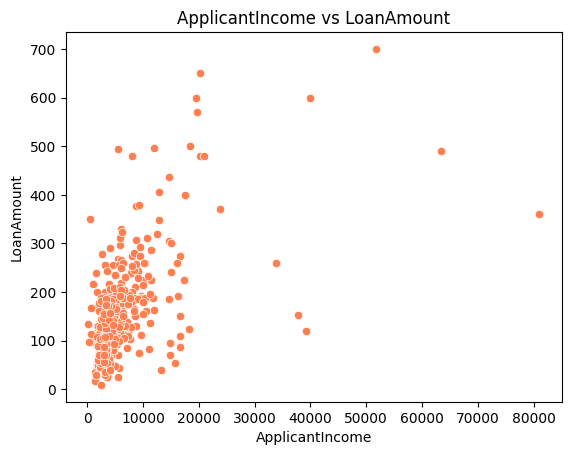

In [271]:
#Scatterplot of ApplicantIncome vs LoanAmount
sns.scatterplot(data = data ,x="ApplicantIncome", y ="LoanAmount", color = "coral")
plt.title("ApplicantIncome vs LoanAmount")
plt.xlabel("ApplicantIncome")
plt.ylabel("LoanAmount")
plt.show()

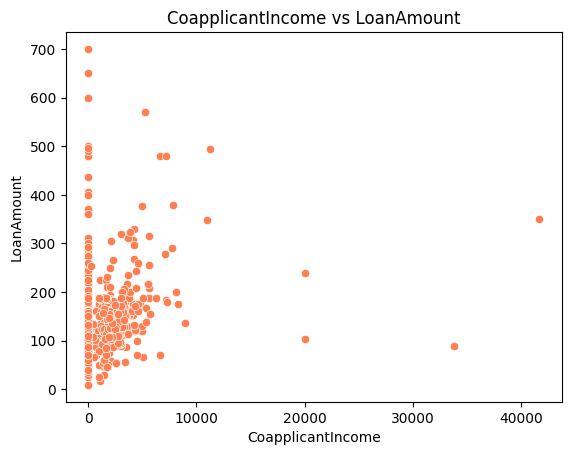

In [272]:
#Scatterplot of CoapplicantIncome vs LoanAmount
sns.scatterplot(data = data ,x="CoapplicantIncome", y ="LoanAmount", color = "coral")
plt.title("CoapplicantIncome vs LoanAmount")
plt.xlabel("CoapplicantIncome")
plt.ylabel("LoanAmount")
plt.show()

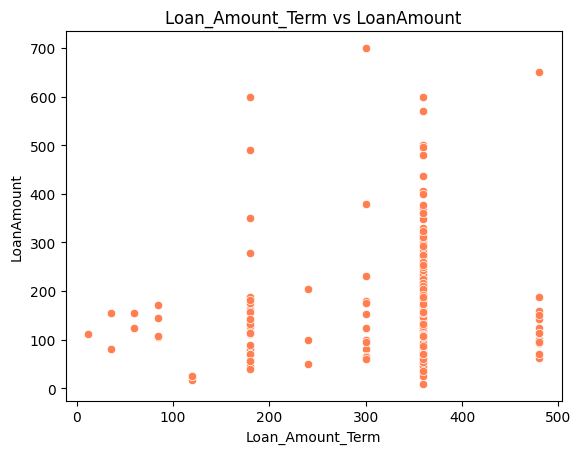

In [273]:
#Scatterplot of Loan_Amount_Term vs LoanAmount
sns.scatterplot(data = data ,x="Loan_Amount_Term", y ="LoanAmount", color = "coral")
plt.title("Loan_Amount_Term vs LoanAmount")
plt.xlabel("Loan_Amount_Term")
plt.ylabel("LoanAmount")
plt.show()

#Multivariate Analysis

In [274]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [280]:
# Drop Loan_ID column
df = df.drop('Loan_ID', axis=1)

KeyError: "['Loan_ID'] not found in axis"

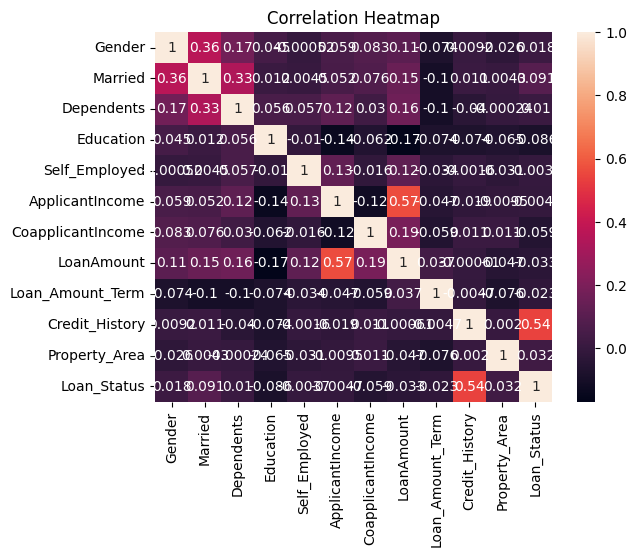

In [289]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Ensure all categorical columns in df are numerically encoded
# The previous LabelEncoder application in cell 0p3TEz2kbmto seems not to have persisted on 'df' or 'df' was overwritten.
# Re-applying LabelEncoder here for robustness.
le = LabelEncoder()
for col in df.select_dtypes(include=np.object_).columns:
    df[col] = le.fit_transform(df[col])

sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.isnull().sum()

#Violin Chart

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Loan_Status', y='ApplicantIncome')

plt.title("Applicant Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='Property_Area', y='LoanAmount')

plt.title("Loan Amount by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Loan Amount")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Loan_Status', y='LoanAmount')

plt.title("Loan Amount Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

#Spliting the Data

In [288]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
x = df.drop("LoanAmount", axis = 1)
y = df["LoanAmount"]

In [ ]:
x.head()

In [ ]:
y.head()

In [ ]:
df.info()

In [ ]:
df.describe()

#Model Selection

In [ ]:
X = df.drop("LoanAmount", axis = 1)
y = df["LoanAmount"]
from sklearn.model_selection import train_test_split
# x = df["ApplicantIncome"]
# y = df["LoanAmount"]
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [ ]:

#statstical model
# 1. Linear model

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

#predicting y
y_pred_lr = lr.predict(x_test)

#r2 score
from sklearn.metrics import r2_score
r2_score_lr = r2_score(y_test, y_pred_lr)

#print r2 score in int
print(r2_score_lr)

In [ ]:
#2 .Decision Tree model

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)

#predicting y
y_pred_dt = dt.predict(x_test)

#r2 score
r2_score_dt = r2_score(y_test,y_pred_dt)

#print r2 score
print(r2_score_dt)

In [ ]:
#3. Random forest model

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train,y_train)


#predicting y
y_pred_rf = rf.predict(x_test)

#r2 score
r2_score_rf = r2_score(y_test,y_pred_rf)

#print r2 score
print(r2_score_rf)


In [ ]:
#4. Xgboost model

from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(x_train,y_train)

#predict y
y_predict_xgb = xgb.predict(x_test)

#r2 score
r2_score_xgb = r2_score(y_test,y_predict_xgb)

#print r2 score
print(r2_score_xgb)

In [ ]:
#Distance Based model
#1.KNN
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(x_train,y_train)

#predicting y
y_pred_knn = knn.predict(x_test)

#r2 score
r2_score_knn = r2_score(y_test,y_pred_knn)

#print r2 score
print(r2_score_knn)

In [ ]:
#MAE and MSE, RMSE

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

mae_rf = mean_absolute_error(y_test,y_pred_rf)
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = root_mean_squared_error(y_test,y_pred_rf)

print(mae_rf)
print(mse_rf)
print(rmse_rf)

In [ ]:
#feature importance to lr model

coefficients = pd.Series(lr.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh', title='Linear Model Coefficients')
plt.show()

#Downloading the Model

In [290]:
#Downloading the lr model
import joblib
joblib.dump(lr,"Loan_Prediction_model.pkl")

['Loan_Prediction_model.pkl']

In [291]:
# downloading model in system
from google.colab import files
files.download("Loan_Prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [292]:
#downloding label encoder
joblib.dump(le, "label_encoder_loan.pkl")
files.download("label_encoder_loan.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB
